File: data/1976-2020-president.csv
Columns: ['year', 'state', 'state_po', 'state_fips', 'state_cen', 'state_ic', 'office', 'candidate', 'party_detailed', 'writein', 'candidatevotes', 'totalvotes', 'version', 'notes', 'party_simplified']

Number of unique years: 12

First 10 rows of the result:
      year                 state party_simplified  candidatevotes  \
1036  2016  DISTRICT OF COLUMBIA         DEMOCRAT          282830   
1037  2016  DISTRICT OF COLUMBIA       REPUBLICAN           12723   
1139  2020  DISTRICT OF COLUMBIA       REPUBLICAN           18586   
1138  2020  DISTRICT OF COLUMBIA         DEMOCRAT          317323   
833   2008  DISTRICT OF COLUMBIA       REPUBLICAN           17367   
832   2008  DISTRICT OF COLUMBIA         DEMOCRAT          245800   
934   2012  DISTRICT OF COLUMBIA         DEMOCRAT          267070   
935   2012  DISTRICT OF COLUMBIA       REPUBLICAN           21381   
730   2004  DISTRICT OF COLUMBIA         DEMOCRAT          202970   
731   2004  DIS

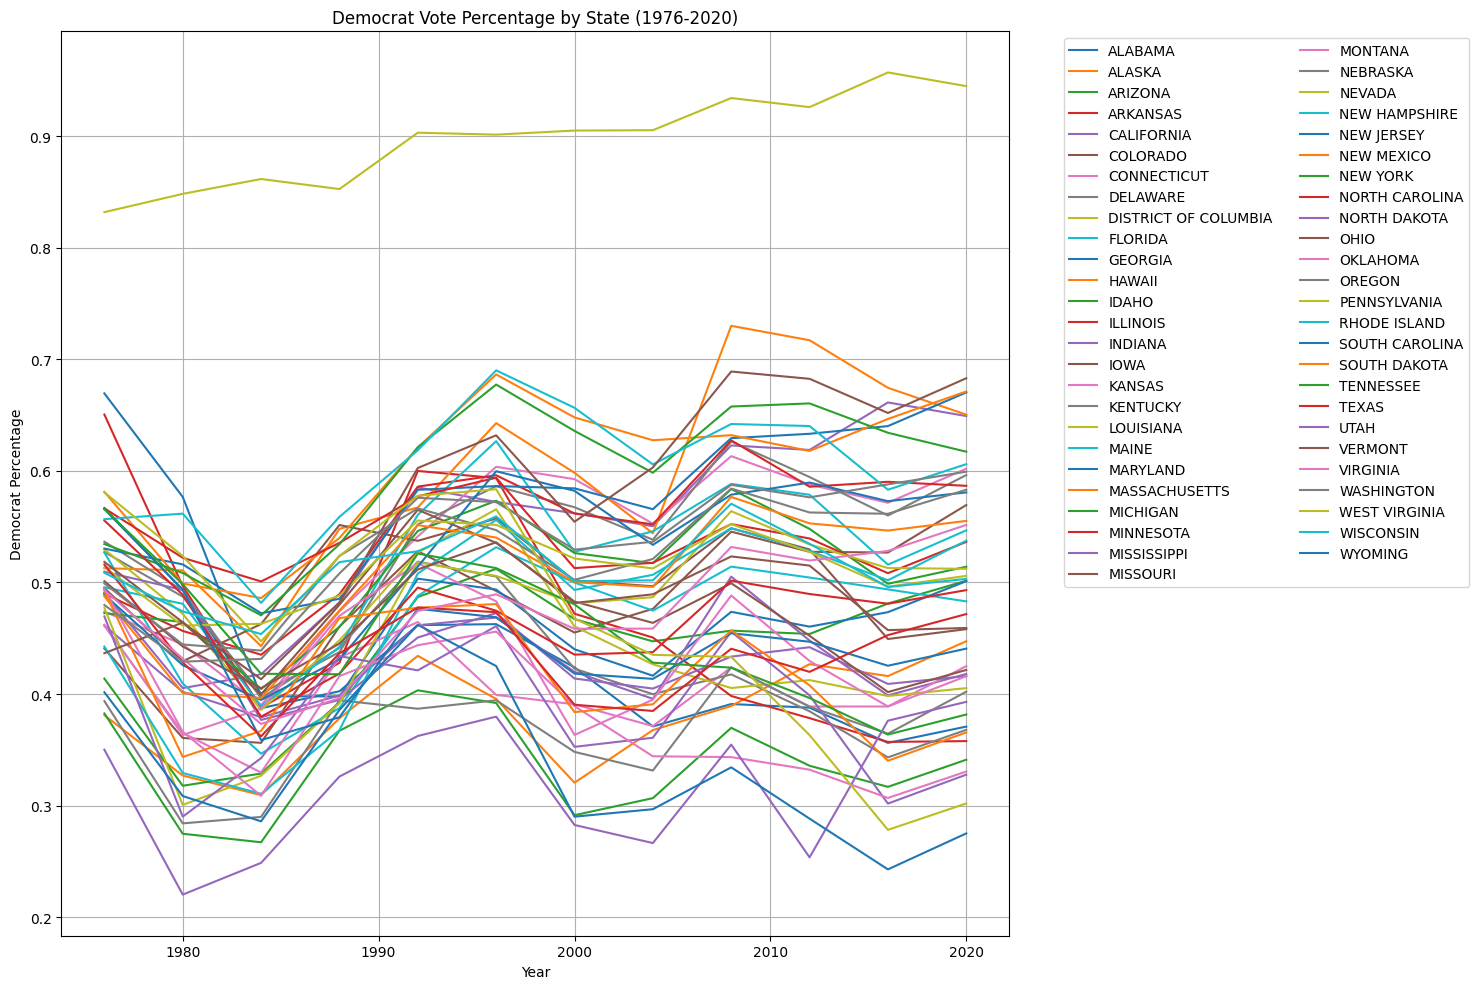

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt

file_path = 'data/1976-2020-president.csv'

try:
    df = pd.read_csv(file_path)
    print(f"File: {file_path}")
    print(f"Columns: {list(df.columns)}")
    
    # Count unique years
    unique_years_count = df['year'].nunique()
    print(f"\nNumber of unique years: {unique_years_count}")
    
    # Filter for Democrat and Republican parties
    df_filtered = df[df['party_simplified'].isin(['DEMOCRAT', 'REPUBLICAN'])].copy()
    
    # Group by year, state, and party to sum votes (handling potential duplicates)
    df_grouped = df_filtered.groupby(['year', 'state', 'party_simplified'])['candidatevotes'].sum().reset_index()
    
    # Pivot to get votes for each party in separate columns
    df_pivot = df_grouped.pivot_table(index=['year', 'state'], columns='party_simplified', values='candidatevotes').reset_index()
    
    # Calculate total two-party votes and Democrat percentage
    df_pivot['total_2party'] = df_pivot['DEMOCRAT'] + df_pivot['REPUBLICAN']
    df_pivot['democrat_percentage'] = df_pivot['DEMOCRAT'] / df_pivot['total_2party']
    
    # Merge the percentage back to the grouped dataframe
    df_final = pd.merge(df_grouped, df_pivot[['year', 'state', 'democrat_percentage']], on=['year', 'state'])
    
    # Select and reorder columns as requested
    result_df = df_final[['year', 'state', 'party_simplified', 'candidatevotes', 'democrat_percentage']]
    result_df = result_df.sort_values(by=['democrat_percentage'], ascending=False)
    print("\nFirst 10 rows of the result:")
    print(result_df.head(10))
    
    # Plotting
    plt.figure(figsize=(15, 10))
    
    # Get unique states
    states = df_pivot['state'].unique()
    
    for state in states:
        state_data = df_pivot[df_pivot['state'] == state]
        plt.plot(state_data['year'], state_data['democrat_percentage'], label=state)
    
    plt.title('Democrat Vote Percentage by State (1976-2020)')
    plt.xlabel('Year')
    plt.ylabel('Democrat Percentage')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error processing data: {e}")